In [143]:
import re
import warnings

import matplotlib.pyplot as plt
import nltk
import pandas as pd
import spacy
from gensim.models import Word2Vec
from nltk.corpus import stopwords
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import (
    GridSearchCV,
    StratifiedKFold,
    cross_val_score,
    train_test_split,
)
from sklearn.naive_bayes import GaussianNB
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from xgboost import XGBClassifier

import numpy as np

warnings.filterwarnings("ignore")
np.random.seed(42)

plt.style.use("seaborn-v0_8-whitegrid")


def ensure_stop_words_downloaded():
    try:
        nltk.data.find("corpora/stopwords")
    except LookupError:
        nltk.download("stopwords")


def ensure_punkt_tab_downloaded():
    try:
        nltk.data.find("tokenizers/punkt")
    except LookupError:
        nltk.download("punkt")


ensure_stop_words_downloaded()
ensure_punkt_tab_downloaded()

In [144]:
# reviews = [
#     "Excellent produit, très satisfait! Livraison rapide, je recommande!",
#     "Pourquoi ce produit est-il si cher pour une si mauvaise qualité?",
#     "Parfait! Exactement ce que j'attendais. Très bon rapport qualité-prix.",
#     "Horrible expérience. Le produit est cassé à la réception.",
#     "Magnifique! Dépassé mes attentes. Un incontournable.",
#     "Décevant. Les photos du site ne correspondaient pas au produit réel.",
#     "Super ! Très content de mon achat. Je rachèterai!",
#     "Pire achat de ma vie. Service client inexistant.",
#     "Bon produit pour le prix. Pas extraordinaire mais correct.",
#     "Absolument terrible. Qualité déplorable et défaut de fabrication.",
#     "Sympa ! Livré rapidement et bien emballé.",
#     "Vraiment nul. Ça ne fonctionne pas du tout.",
#     "Très bien! Produit conforme à la description.",
#     "Complètement inutile, j'ai demandé le remboursement.",
#     "Excellent service et produit de qualité!",
#     "Déception totale. N'achetez pas ce produit.",
# ]

# labels = [1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0]  # 1 = positif, 0 = négatif

In [145]:
reviews = [
    "Très bon produit, je suis vraiment satisfait de mon achat.",
    "La qualité est catastrophique, je regrette cet achat.",
    "Fonctionne parfaitement depuis la première utilisation.",
    "Produit inutilisable, il est tombé en panne immédiatement.",
    "Super rapport qualité-prix, je recommande sans hésiter.",
    "Très déçu, le produit ne correspond pas du tout à la description.",
    "Livraison rapide et produit conforme, très content.",
    "Mauvaise qualité de fabrication, je ne recommande pas.",
    "Produit efficace et facile à utiliser.",
    "Expérience très négative, je suis vraiment mécontent.",
    "Très bon achat, je l'utilise tous les jours.",
    "Le produit est arrivé abîmé, grosse déception.",
    "Excellente surprise, bien mieux que prévu.",
    "Qualité vraiment médiocre pour le prix.",
    "Parfait, exactement ce que je cherchais.",
    "Ne fonctionne déjà plus après quelques jours.",
    "Produit solide et bien conçu.",
    "Très mauvaise expérience avec ce produit.",
    "Je suis ravi, tout fonctionne très bien.",
    "Complètement inutile, argent perdu.",
    "Bonne qualité et utilisation simple.",
    "Déçu par la performance du produit.",
    "Très satisfait, je recommande vivement.",
    "Produit fragile qui s'est cassé rapidement.",
    "Excellent produit, très pratique.",
    "Vraiment décevant, je ne rachèterai pas.",
    "Très bon service et produit fiable.",
    "Problème dès la première utilisation.",
    "Produit top, conforme aux attentes.",
    "La qualité laisse vraiment à désirer.",
    "Super achat, je suis très content.",
    "Très mauvaise finition du produit.",
    "Fonctionne très bien, rien à redire.",
    "Produit défectueux à la réception.",
    "Très agréable à utiliser.",
    "Je regrette cet achat.",
    "Produit performant et fiable.",
    "Impossible à utiliser correctement.",
    "Très bon produit pour ce prix.",
    "Très mauvaise qualité.",
    "Je recommande ce produit sans hésiter.",
    "Complètement déçu par la qualité.",
    "Produit très pratique au quotidien.",
    "Ne correspond pas du tout aux photos.",
    "Très bon achat, satisfait.",
    "Produit inutilisable dès l'ouverture.",
    "Qualité excellente, très content.",
    "Grosse déception après réception.",
    "Produit efficace et bien pensé.",
    "Vraiment nul, je déconseille.",
    "Fonctionne parfaitement, très satisfait.",
    "Produit cassé au bout de deux jours.",
    "Très bon produit, facile à utiliser.",
    "Très mauvaise expérience d'utilisation.",
    "Je suis très content de cet achat.",
    "Le produit ne marche pas.",
    "Bonne qualité globale.",
    "Produit très fragile.",
    "Super produit, je recommande.",
    "Qualité très décevante.",
    "Très satisfait de la performance.",
    "Problème technique dès le départ.",
    "Excellent rapport qualité-prix.",
    "Produit vraiment mauvais.",
    "Très bonne surprise.",
    "Je ne recommande absolument pas.",
    "Produit pratique et efficace.",
    "Très mauvaise conception.",
    "Très bon achat pour ce prix.",
    "Produit inutilisable.",
    "Je suis très satisfait.",
    "Très déçu par cet achat.",
    "Produit conforme et efficace.",
    "Qualité vraiment mauvaise.",
    "Super produit, très content.",
    "Produit cassé rapidement.",
    "Très bon fonctionnement.",
    "Très mauvaise qualité de fabrication.",
    "Produit simple et efficace.",
    "Déception totale.",
    "Très satisfait de mon achat.",
    "Produit défectueux.",
    "Excellent produit.",
    "Très mauvais achat.",
    "Très pratique et utile.",
    "Produit vraiment décevant.",
    "Je recommande fortement.",
    "Je regrette cet achat.",
    "Produit fiable et efficace.",
    "Très mauvaise surprise.",
    "Très bon produit.",
    "Produit de mauvaise qualité.",
    "Fonctionne très bien.",
    "Ne fonctionne pas du tout.",
    "Très satisfait du résultat.",
    "Très déçu du produit.",
    "Produit parfait pour mon usage.",
    "Produit complètement raté.",
    "Très satisfait de ce produit, il dépasse mes attentes.",
    "Produit défectueux dès la première utilisation.",
]

labels = [
    1,
    0,
    1,
    0,
    1,
    0,
    1,
    0,
    1,
    0,
    1,
    0,
    1,
    0,
    1,
    0,
    1,
    0,
    1,
    0,
    1,
    0,
    1,
    0,
    1,
    0,
    1,
    0,
    1,
    0,
    1,
    0,
    1,
    0,
    1,
    0,
    1,
    0,
    1,
    0,
    1,
    0,
    1,
    0,
    1,
    0,
    1,
    0,
    1,
    0,
    1,
    0,
    1,
    0,
    1,
    0,
    1,
    0,
    1,
    0,
    1,
    0,
    1,
    0,
    1,
    0,
    1,
    0,
    1,
    0,
    1,
    0,
    1,
    0,
    1,
    0,
    1,
    0,
    1,
    0,
    1,
    0,
    1,
    0,
    1,
    0,
    1,
    0,
    1,
    0,
    1,
    0,
    1,
    0,
    1,
    0,
    1,
    0,
    1,
    0,
]


## Tâches

### Tâche 1 : Préparation des données
1. Nettoyez les avis (utilisez l'exercice 1)
2. Vectorisez avec TF-IDF (utilisez l'exercice 2)
3. Divisez en ensemble d'entraînement et de test (80/20)
4. Vérifiez l'équilibre des classes dans train et test

**Attendus** : Données propres et vectorisées, split train/test validé

In [146]:
nlp = spacy.load("fr_core_news_sm")
stop_words = set(stopwords.words("french"))
stop_words.discard("n")
stop_words.discard("ne")
stop_words.discard("pas")
stop_words.discard("plus")
stop_words.discard("non")


def preprocessor(sentence: str) -> list[str]:
    sentence = sentence.lower()
    # sentence = unidecode(sentence)
    sentence = re.sub(r"([a-z])'", " ", sentence)
    sentence = re.sub(r"[^\w\s]", "", sentence)
    doc = nlp(sentence)
    tokens = [
        token.lemma_ for token in doc if token.is_alpha and token.text not in stop_words
    ]
    return " ".join(tokens)


reviews_clean = [preprocessor(review) for review in reviews]

In [147]:
tfidf = TfidfVectorizer(
    max_features=100,
    ngram_range=(1, 2),
    min_df=1,
    max_df=0.95,
)

X_tfidf = tfidf.fit_transform(reviews_clean)

In [148]:
X_train, X_test, y_train, y_test = train_test_split(
    X_tfidf, labels, test_size=0.2, stratify=labels, random_state=42
)

print("Proportion label 1 dans labels :", np.sum(labels) / len(labels))
print("Proportion label 1 dans y_train :", np.sum(y_train) / len(y_train))
print("Proportion label 1 dans y_test :", np.sum(y_test) / len(y_test))

Proportion label 1 dans labels : 0.5
Proportion label 1 dans y_train : 0.5
Proportion label 1 dans y_test : 0.5


### Tâche 2 : Logistic Regression
1. Entraînez une Logistic Regression sur l'ensemble d'entraînement
2. Prédisez sur l'ensemble de test
3. Calculez les métriques :
   - Accuracy
   - Precision
   - Recall
   - F1-score
4. Affichez une matrice de confusion

**Attendus** : Modèle entraîné, métriques calculées, matrice de confusion

Accuracy train : 1.0
Accuracy test : 0.85
Precision : 0.8181818181818182
Recall : 0.9
F1 score : 0.8571428571428571


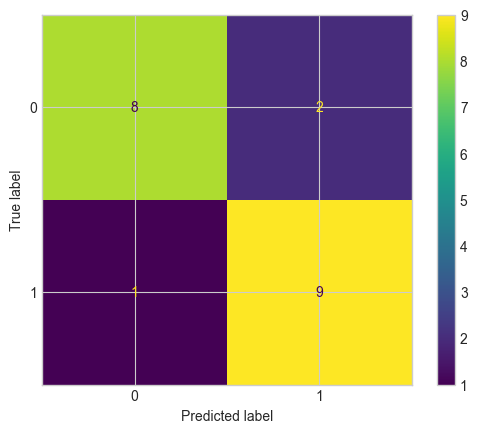

In [149]:
lr = LogisticRegression(random_state=42)

lr_fitted = lr.fit(X_train, y_train)

lr_y_pred_train = lr_fitted.predict(X_train)
lr_y_pred_test = lr_fitted.predict(X_test)

print("Accuracy train :", accuracy_score(y_train, lr_y_pred_train))
print("Accuracy test :", accuracy_score(y_test, lr_y_pred_test))
print("Precision :", precision_score(y_test, lr_y_pred_test))
print("Recall :", recall_score(y_test, lr_y_pred_test))
print("F1 score :", f1_score(y_test, lr_y_pred_test))

lr_cm = confusion_matrix(y_test, lr_y_pred_test)
ConfusionMatrixDisplay(lr_cm).plot()

### Tâche 3 : Support Vector Machine (SVM)
1. Entraînez un SVM avec kernel 'linear'
2. Comparez les performances avec Logistic Regression
3. Testez différents kernels : 'rbf', 'poly'
4. Quel kernel donne les meilleures performances?

**Attendus** : SVM entraîné, comparaison kernels, recommandation

SCV, kernel : linear
  Accuracy train : 1.0
  Accuracy test : 0.8
  Precision : 0.75
  Recall : 0.9
  F1 score : 0.8181818181818182

SCV, kernel : rbf
  Accuracy train : 1.0
  Accuracy test : 0.8
  Precision : 0.75
  Recall : 0.9
  F1 score : 0.8181818181818182

SCV, kernel : poly
  Accuracy train : 1.0
  Accuracy test : 0.8
  Precision : 0.75
  Recall : 0.9
  F1 score : 0.8181818181818182



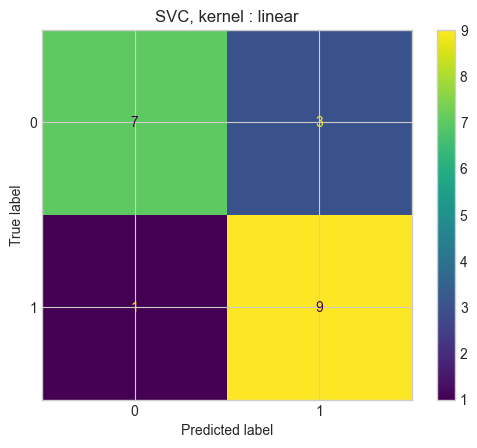

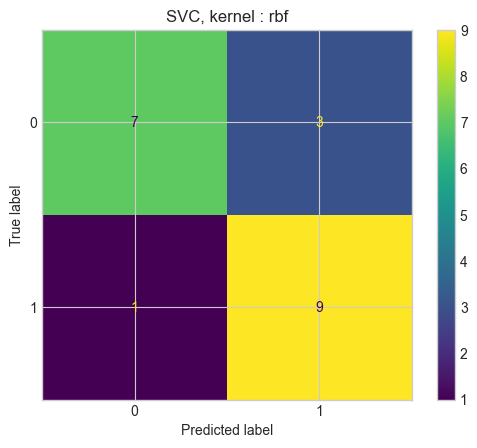

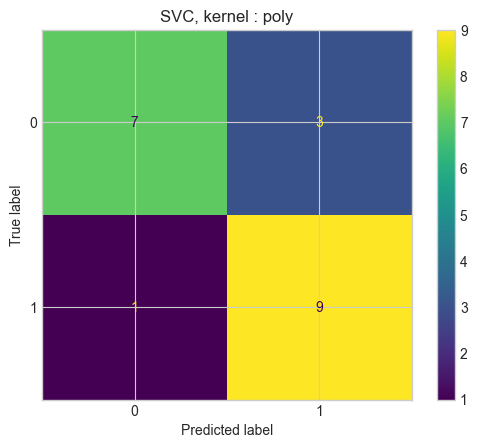

In [150]:
for kernel in ["linear", "rbf", "poly"]:
    svc = SVC(random_state=42, kernel=kernel)

    svc_fitted = svc.fit(X_train, y_train)

    svc_y_pred_train = svc_fitted.predict(X_train)
    svc_y_pred_test = svc_fitted.predict(X_test)

    print("SCV, kernel :", kernel)
    print("  Accuracy train :", accuracy_score(y_train, svc_y_pred_train))
    print("  Accuracy test :", accuracy_score(y_test, svc_y_pred_test))
    print("  Precision :", precision_score(y_test, svc_y_pred_test))
    print("  Recall :", recall_score(y_test, svc_y_pred_test))
    print("  F1 score :", f1_score(y_test, svc_y_pred_test))
    print()

    svc_cm = confusion_matrix(y_test, svc_y_pred_test)
    ConfusionMatrixDisplay(svc_cm).plot()
    plt.title(f"SVC, kernel : {kernel}")

### Tâche 4 : Naive Bayes
1. Entraînez un Naive Bayes Multinomial
2. Comparez avec les modèles précédents
3. Analysez les probabilités de classe pour 3 avis de test
4. Avantages/inconvénients de Naive Bayes?

**Attendus** : Naive Bayes entraîné, analyse comparée, recommandation

Accuracy train : 1.0
Accuracy test : 0.85
Precision : 0.8181818181818182
Recall : 0.9
F1 score : 0.8571428571428571


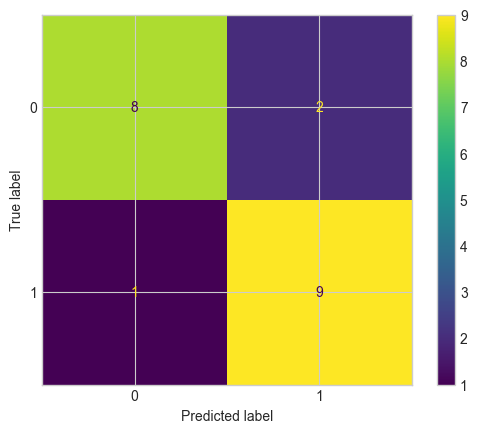

In [151]:
nb = GaussianNB()

nb_fitted = nb.fit(X_train.toarray(), y_train)

nb_y_pred_train = nb_fitted.predict(X_train.toarray())
nb_y_pred_test = nb_fitted.predict(X_test.toarray())

print("Accuracy train :", accuracy_score(y_train, nb_y_pred_train))
print("Accuracy test :", accuracy_score(y_test, nb_y_pred_test))
print("Precision :", precision_score(y_test, nb_y_pred_test))
print("Recall :", recall_score(y_test, nb_y_pred_test))
print("F1 score :", f1_score(y_test, nb_y_pred_test))

nb_cm = confusion_matrix(y_test, nb_y_pred_test)
ConfusionMatrixDisplay(nb_cm).plot()

In [152]:
nb_y_proba_test = nb_fitted.predict_proba(X_test.toarray())

for y_true, y_pred, proba in zip(y_test[:3], nb_y_pred_test[:3], nb_y_proba_test[:3]):
    print(f"True label : {y_true}, Predict label : {y_pred}, Probability : {proba}")

True label : 1, Predict label : 1, Probability : [0. 1.]
True label : 1, Predict label : 1, Probability : [8.41483614e-43 1.00000000e+00]
True label : 1, Predict label : 1, Probability : [0. 1.]


### Tâche 5 : Feature importance et interprétabilité
1. Extractez les coefficients de Logistic Regression
2. Identifiez les 10 termes les plus positifs et les 10 plus négatifs
3. Visualisez-les (graphique en barres)
4. Analysez : ces termes ont-ils du sens?

**Attendus** : Feature importance visualisée, analyse critique

In [153]:
lr_feature_importance = pd.DataFrame(
    {"feature": tfidf.get_feature_names_out(), "importance": lr_fitted.coef_[0]}
)
lr_feature_importance["abs_importance"] = np.abs(lr_feature_importance["importance"])
lr_feature_importance = lr_feature_importance.sort_values(
    by="abs_importance", ascending=False
)


print("Top 10 termes positifs")
top_features_positives = lr_feature_importance.nlargest(10, "importance")
print(top_features_positives)

top_features_negatives = lr_feature_importance.nsmallest(10, "importance")
print("\nTop 10 termes négatives")
print(top_features_negatives)

Top 10 termes positifs
           feature  importance  abs_importance
4              bon    1.009914        1.009914
25        efficace    0.949075        0.949075
80       satisfait    0.936254        0.936254
94  très satisfait    0.799281        0.799281
89        très bon    0.752206        0.752206
87            très    0.726135        0.726135
26       excellent    0.693958        0.693958
54        pratique    0.644999        0.644999
97        utiliser    0.609167        0.609167
13        conforme    0.570788        0.570788

Top 10 termes négatives
         feature  importance  abs_importance
42       mauvais   -1.188062        1.188062
92  très mauvais   -0.919913        0.919913
98      vraiment   -0.805498        0.805498
51           pas   -0.735311        0.735311
45            ne   -0.710816        0.710816
12  complètement   -0.636382        0.636382
19     déception   -0.618505        0.618505
11      ce achat   -0.491196        0.491196
10            ce   -0.491196  

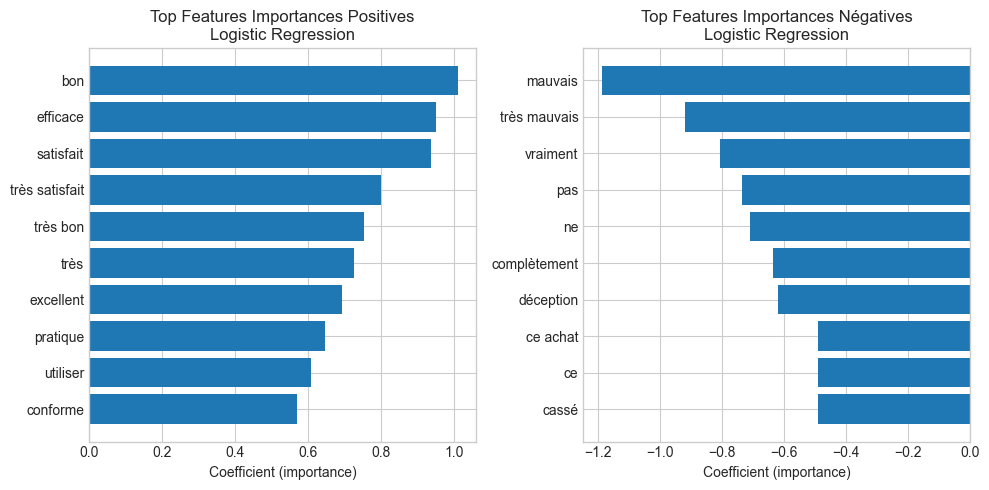

In [154]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

ax1 = axes[0]
ax1.barh(top_features_positives["feature"], top_features_positives["importance"])
ax1.set_xlabel("Coefficient (importance)")
ax1.set_title("Top Features Importances Positives\nLogistic Regression")
ax1.invert_yaxis()

ax2 = axes[1]
ax2.barh(top_features_negatives["feature"], top_features_negatives["importance"])
ax2.set_xlabel("Coefficient (importance)")
ax2.set_title("Top Features Importances Négatives\nLogistic Regression")
ax2.invert_yaxis()

plt.tight_layout()
plt.show()

### Tâche 6 : Tuning et optimisation
1. Utilisez GridSearchCV pour optimiser les paramètres de SVM
2. Paramètres à tester : C=[0.1, 1, 10], kernel=['linear', 'rbf']
3. Affichez le meilleur modèle et ses paramètres
4. Comparez les performances avant/après tuning

**Attendus** : Modèle optimisé, comparaison avant/après, meilleurs paramètres

Fitting 3 folds for each of 3600 candidates, totalling 10800 fits
Meilleurs parametres: {'svc__C': 10, 'svc__gamma': 'scale', 'svc__kernel': 'linear', 'tfidf__max_df': 0.8, 'tfidf__min_df': 1, 'tfidf__ngram_range': (1, 2), 'tfidf__sublinear_tf': True}
Meilleur score CV:    0.9753

Metrics :
Accuracy train : 1.0
Accuracy test  : 0.8
Precision      : 0.75
Recall         : 0.9
F1 score       : 0.8181818181818182


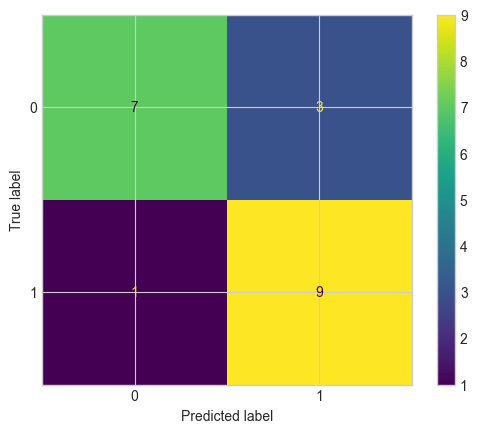

In [168]:
pipeline = Pipeline(
    steps=[
        ("tfidf", TfidfVectorizer()),
        ("svc", SVC(random_state=42, probability=True)),
    ]
)

reviews_train, reviews_test, labels_train, labels_test = train_test_split(
    reviews_clean, labels, test_size=0.2, stratify=labels, shuffle=True, random_state=42
)

param_grid = {
    "tfidf__ngram_range": [(1, 1), (1, 2)],
    "tfidf__min_df": [1, 2, 3],
    "tfidf__max_df": [0.8, 0.85, 0.9, 0.95],
    "tfidf__sublinear_tf": [True, False],
    "svc__C": [0.01, 0.1, 1, 10, 100],
    "svc__kernel": ["linear", "rbf", "poly"],
    "svc__gamma": ["scale", "auto", 0.1, 0.01, 0.001],
}

grid = GridSearchCV(
    pipeline,
    param_grid,
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=42),
    scoring="f1_macro",
    n_jobs=-1,
    verbose=1,
    return_train_score=True,
)

grid.fit(reviews_train, labels_train)

print(f"Meilleurs parametres: {grid.best_params_}")
print(f"Meilleur score CV:    {grid.best_score_:.4f}")

best_model_fitted = grid.best_estimator_

best_model_y_pred_train = best_model_fitted.predict(reviews_train)
best_model_y_pred_test = best_model_fitted.predict(reviews_test)

print("\nMetrics :")
print("Accuracy train :", accuracy_score(labels_train, best_model_y_pred_train))
print("Accuracy test  :", accuracy_score(labels_test, best_model_y_pred_test))
print("Precision      :", precision_score(labels_test, best_model_y_pred_test))
print("Recall         :", recall_score(labels_test, best_model_y_pred_test))
print("F1 score       :", f1_score(labels_test, best_model_y_pred_test))

best_model_cm = confusion_matrix(labels_test, best_model_y_pred_test)
ConfusionMatrixDisplay(best_model_cm).plot()

### Tâche 7 : Évaluation sur données réelles
1. Testez sur 5 nouveaux avis non vus (positifs et négatifs mélangés)
2. Affichez :
   - Le texte brut
   - La prédiction
   - La probabilité de confiance
3. Analysez les erreurs : pourquoi les faux positifs/négatifs?
4. Comment améliorer le modèle?

**Attendus** : Prédictions sur données nouvelles, analyse d'erreurs

In [156]:
reviews_new = [
    "Très satisfait de cet achat. Produit solide et livraison impeccable.",
    "Produit médiocre. Il s'est cassé après deux utilisations.",
    "Bonne surprise! Fonctionne parfaitement et facile à utiliser.",
    "Très déçu. La qualité est vraiment en dessous de ce qui était annoncé.",
    "Excellent! Installation rapide et résultat au top.",
]

labels_new = [1, 0, 1, 0, 1]

reviews_new_clean = [preprocessor(review) for review in reviews_new]

best_model_y_pred_new = best_model_fitted.predict(reviews_new_clean)
best_model_y_proba_new = best_model_fitted.predict_proba(reviews_new_clean)

for review, y_true, y_pred, proba in zip(
    reviews_new, labels_new, best_model_y_pred_new, best_model_y_proba_new
):
    print("Review :", review)
    print("True Label :", y_true)
    print("Predict Label :", y_pred)
    print("Probability :", proba)
    print()

Review : Très satisfait de cet achat. Produit solide et livraison impeccable.
True Label : 1
Predict Label : 1
Probability : [0.15324227 0.84675773]

Review : Produit médiocre. Il s'est cassé après deux utilisations.
True Label : 0
Predict Label : 0
Probability : [0.98890091 0.01109909]

Review : Bonne surprise! Fonctionne parfaitement et facile à utiliser.
True Label : 1
Predict Label : 1
Probability : [0.00457577 0.99542423]

Review : Très déçu. La qualité est vraiment en dessous de ce qui était annoncé.
True Label : 0
Predict Label : 0
Probability : [0.99889925 0.00110075]

Review : Excellent! Installation rapide et résultat au top.
True Label : 1
Predict Label : 1
Probability : [0.00878119 0.99121881]



## Bonus (Optionnel)

- Testez d'autres classifieurs : Random Forest, XGBoost
- Implémentez une validation croisée (K-Fold CV)
- Créez une ROC curve et AUC score
- Utilisez Word2Vec embeddings à la place de TF-IDF
- Appliquez du SMOTE pour gérer un déséquilibre de classes

### RandomForest et XGBoost

Accuracy train : 1.0
Accuracy test : 0.8
Precision : 0.875
Recall : 0.7
F1 score : 0.7777777777777778


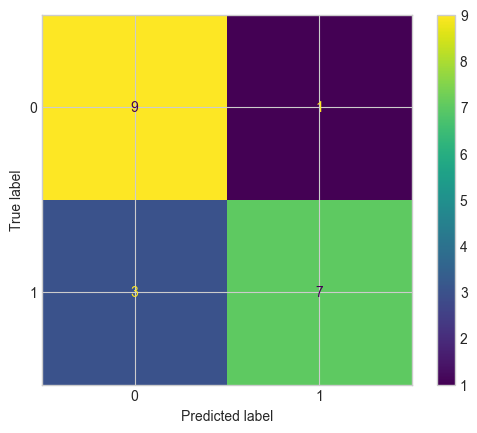

In [157]:
rf = RandomForestClassifier(random_state=42)

rf_fitted = rf.fit(X_train, y_train)

rf_y_pred_train = rf_fitted.predict(X_train)
rf_y_pred_test = rf_fitted.predict(X_test)

print("Accuracy train :", accuracy_score(y_train, rf_y_pred_train))
print("Accuracy test :", accuracy_score(y_test, rf_y_pred_test))
print("Precision :", precision_score(y_test, rf_y_pred_test))
print("Recall :", recall_score(y_test, rf_y_pred_test))
print("F1 score :", f1_score(y_test, rf_y_pred_test))

rf_cm = confusion_matrix(y_test, rf_y_pred_test)
ConfusionMatrixDisplay(rf_cm).plot()

Accuracy train : 0.9625
Accuracy test : 0.6
Precision : 0.6666666666666666
Recall : 0.4
F1 score : 0.5


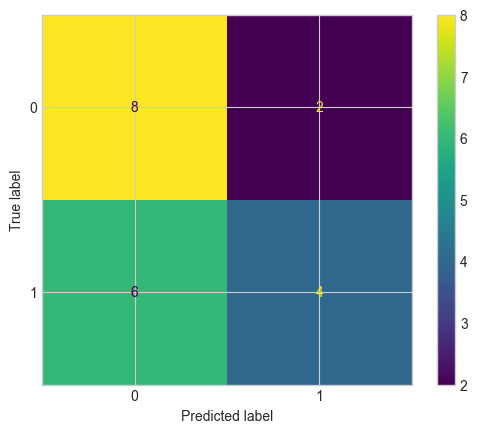

In [158]:
xgb = XGBClassifier(random_state=42)

xgb_fitted = xgb.fit(X_train, y_train)

xgb_y_pred_train = xgb_fitted.predict(X_train)
xgb_y_pred_test = xgb_fitted.predict(X_test)

print("Accuracy train :", accuracy_score(y_train, xgb_y_pred_train))
print("Accuracy test :", accuracy_score(y_test, xgb_y_pred_test))
print("Precision :", precision_score(y_test, xgb_y_pred_test))
print("Recall :", recall_score(y_test, xgb_y_pred_test))
print("F1 score :", f1_score(y_test, xgb_y_pred_test))

xgb_cm = confusion_matrix(y_test, xgb_y_pred_test)
ConfusionMatrixDisplay(xgb_cm).plot()

### validation croisée

In [159]:
scores = cross_val_score(
    pipeline,
    reviews_train,
    labels_train,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring="f1_macro",
)

print(f"F1 moyen : {scores.mean():.4f} (+/- {scores.std():.4f})")

F1 moyen : 0.9749 (+/- 0.0307)


### ROC AUC

In [160]:
best_model_y_proba = best_model_fitted.predict_proba(reviews_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, best_model_y_proba)
auc = roc_auc_score(y_test, best_model_y_proba)

print(f"AUC : {auc}")

AUC : 0.9299999999999999


In [161]:
youden_j = tpr - fpr
optimal_idx = np.argmax(youden_j)
optimal_threshold = thresholds[optimal_idx]
print("Seuil optimal : ", optimal_threshold)

Seuil optimal :  0.6447243536034178


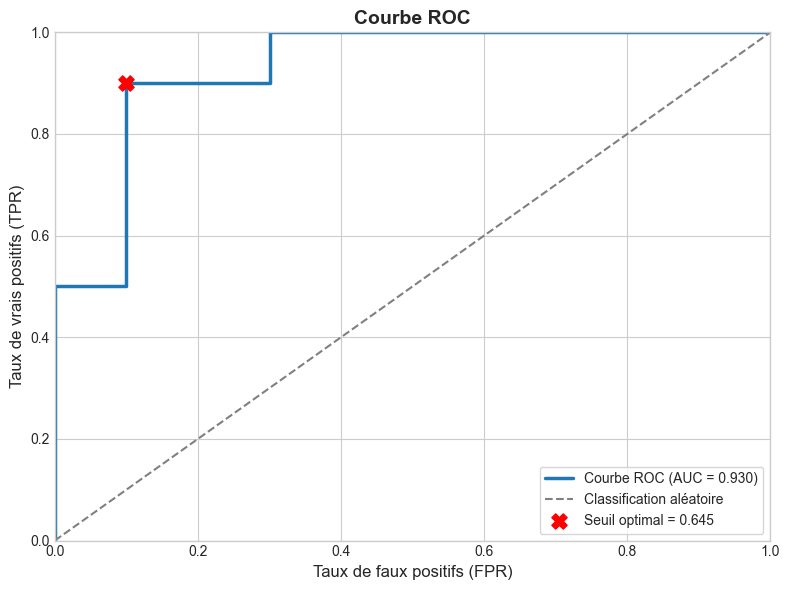

In [162]:
fig, ax = plt.subplots(figsize=(8, 6))

ax.plot(fpr, tpr, color="#1f77b4", linewidth=2.5, label=f"Courbe ROC (AUC = {auc:.3f})")

ax.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    color="gray",
    linewidth=1.5,
    label="Classification aléatoire",
)

ax.scatter(
    fpr[optimal_idx],
    tpr[optimal_idx],
    color="red",
    s=120,
    marker="X",
    label=f"Seuil optimal = {optimal_threshold:.3f}",
    zorder=3,
)

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_title("Courbe ROC", fontsize=14, fontweight="bold")
ax.set_xlabel("Taux de faux positifs (FPR)", fontsize=12)
ax.set_ylabel("Taux de vrais positifs (TPR)", fontsize=12)
ax.legend(loc="lower right", frameon=True)

plt.tight_layout()
plt.show()

### Word2Vec

Accuracy train : 0.9125
Accuracy test : 0.75
Precision : 0.8571428571428571
Recall : 0.6
F1 score : 0.7058823529411765


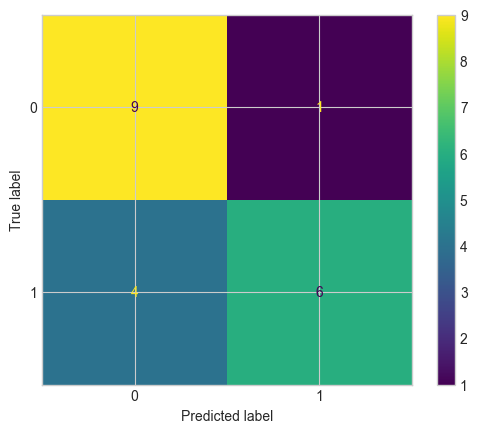

In [163]:
reviews_tokenized = [sentence.split() for sentence in reviews_clean]

w2v = Word2Vec(
    sentences=reviews_tokenized,
    vector_size=100,
    window=5,
    min_count=1,
    sg=1,
    epochs=20,
)


def sentence_vector(sentence, model):
    words = sentence.split()
    word_vectors = [model.wv[word] for word in words if word in model.wv]

    if len(word_vectors) == 0:
        return np.zeros(model.vector_size)

    return np.mean(word_vectors, axis=0)


X_w2v = np.array([sentence_vector(review, w2v) for review in reviews_clean])

X_train_w2v, X_test_w2v, y_train_w2v, y_test_w2v = train_test_split(
    X_w2v, labels, test_size=0.2, stratify=labels, random_state=42
)

lr_w2v = LogisticRegression(random_state=42, max_iter=1000)

lr_w2v_fitted = lr_w2v.fit(X_train_w2v, y_train_w2v)

lr_w2v_y_pred_train = lr_w2v_fitted.predict(X_train_w2v)
lr_w2v_y_pred_test = lr_w2v_fitted.predict(X_test_w2v)

print("Accuracy train :", accuracy_score(y_train_w2v, lr_w2v_y_pred_train))
print("Accuracy test :", accuracy_score(y_test_w2v, lr_w2v_y_pred_test))
print("Precision :", precision_score(y_test_w2v, lr_w2v_y_pred_test))
print("Recall :", recall_score(y_test_w2v, lr_w2v_y_pred_test))
print("F1 score :", f1_score(y_test_w2v, lr_w2v_y_pred_test))

lr_w2v_cm = confusion_matrix(y_test_w2v, lr_w2v_y_pred_test)
ConfusionMatrixDisplay(lr_w2v_cm).plot()
plt.show()